# Week 4 — Communities on the philosophers

New network this week: 1,444 philosophers born before 1900, linked when one
Wikipedia article links to another, with a **weight** counting how many times.

This notebook produces every figure and number in
[the week 4 post](../weeks/week4/week4.html). Four questions:

1. Louvain vs Infomap — do they agree, and which tells the better history?
2. Which tradition is Aristotle *really* in?
3. Where does the disparity-filter backbone break, and whose links break it?
4. Does the weighted network tell a different story?

In [1]:
import sys
sys.path.append("../src")

import collections, json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import louvain_communities, modularity, k_clique_communities
from sklearn.metrics import normalized_mutual_info_score as nmi
import infomap

import marvel                       # our shared helpers: palette, save()
marvel.use_site_style()

PAL = ["#1F4E79", "#A8182A", "#2E6B4F", "#7A4E9B", "#C0761B", "#1E7F8C", "#8C5A3C", "#5B6B7A"]
GREY = "#7C89A8"

## 1. Loading the weighted network

The edge file is directed with a weight on each arrow. The header says to sum
both directions for the undirected weighted network, so `A -> B` weight 3 and
`B -> A` weight 2 become one undirected link of weight 5.

In [2]:
G = marvel.load_philosophers()       # nodes added before edges; weights summed both ways
name = nx.get_node_attributes(G, "name")
era  = nx.get_node_attributes(G, "era")
short = lambda v: name[v]

GC = G.subgraph(max(nx.connected_components(G), key=len)).copy()
n, m = GC.number_of_nodes(), GC.number_of_edges()
W = np.array([d["weight"] for _, _, d in GC.edges(data=True)])

print(f"giant component: {n} philosophers, {m} links     course page: 1374 / 9139")
print(f"weights 1..{W.max()}, {(W == 1).sum()} of weight 1     course page: 1..24, 5899")
assert (n, m) == (1374, 9139)

deg = dict(GC.degree())
strength = dict(GC.degree(weight="weight"))
order = list(GC.nodes())
idx = {v: i for i, v in enumerate(order)}

giant component: 1374 philosophers, 9139 links     course page: 1374 / 9139
weights 1..24, 5899 of weight 1     course page: 1..24, 5899


## 2. Louvain, and the two checks we owe it

Week 2's lesson applies directly: a modularity without a null model is not a
result. A shuffled version of this network still scores around 0.23, so the
number that matters is the distance from that, not 0.5 itself.

In [3]:
def labels_of(comms):
    lab = np.zeros(len(order), dtype=int)
    for c, com in enumerate(comms):
        for v in com:
            lab[idx[v]] = c
    return lab

louv = louvain_communities(GC, weight=None, seed=42)
Q = modularity(GC, louv, weight=None)
lab_lu = labels_of(louv)
print(f"Louvain: {len(louv)} communities, Q = {Q:.4f}     course page: 8-10, Q 0.500-0.508")

cname = {}
for c in set(lab_lu):
    mem = [order[i] for i in range(len(order)) if lab_lu[i] == c]
    cname[c] = short(max(mem, key=lambda v: deg[v]))

for c in sorted(set(lab_lu), key=lambda c: -sum(lab_lu == c)):
    mem = [order[i] for i in range(len(order)) if lab_lu[i] == c]
    top = sorted(mem, key=lambda v: -deg[v])[:5]
    print(f"  {len(mem):>4}  {', '.join(short(v) for v in top)}")

Louvain: 8 communities, Q = 0.5059     course page: 8-10, Q 0.500-0.508
   266  René Descartes, Gottfried Wilhelm Leibniz, Baruch Spinoza, John Locke, David Hume
   260  Aristotle, Plato, Cicero, Diogenes Laertius, Heraclitus
   250  Immanuel Kant, Georg Wilhelm Friedrich Hegel, Friedrich Nietzsche, Karl Marx, Arthur Schopenhauer
   200  Thomas Aquinas, Augustine of Hippo, Jesus, Dante Alighieri, Martin Luther
   181  The Buddha, Confucius, Zhu Xi, Adi Shankara, Mao Zedong
   155  Bertrand Russell, Henri Bergson, William James, Albert Einstein, Charles Darwin
    60  Maimonides, Al-Ghazali, Ibn Khaldun, Solomon ibn Gabirol, Abraham ibn Ezra
     2  Jules Barthélemy-Saint-Hilaire, Jules Lequier


In [4]:
# stability: the same algorithm, different seeds
runs = [labels_of(louvain_communities(GC, weight=None, seed=s)) for s in range(5)]
pairs = [nmi(runs[i], runs[j]) for i in range(5) for j in range(i+1, 5)]
print(f"NMI between Louvain runs: {min(pairs):.3f} to {max(pairs):.3f}"
      f"     course page: 0.65-0.83")

# ground truth-ish: the century each philosopher is listed under
lab_era = pd.factorize(pd.Series([era[v] for v in order]))[0]
print(f"NMI vs era: {nmi(lab_lu, lab_era):.4f}     course page: 0.40")
print("The communities are traditions, not centuries.")

NMI between Louvain runs: 0.653 to 0.833     course page: 0.65-0.83
NMI vs era: 0.4131     course page: 0.40
The communities are traditions, not centuries.


## 3. Infomap — the second algorithm you always run

Modularity asks *which split has more internal links than chance expects*.
Infomap asks something unrelated: *put a random walker on the network and
describe its path — which grouping makes the description shortest?* Two
different questions, so where they disagree is worth reading.

In [5]:
im_map = marvel.infomap_communities(GC)          # node -> module id
lab_im = np.array([im_map[v] for v in order])
im_comms = [set(np.array(order)[lab_im == k]) for k in sorted(set(lab_im))]

print(f"Infomap: {len(set(lab_im))} modules")
print(f"Louvain:  {len(louv)} communities")
print()
print(f"NMI between them: {nmi(lab_lu, lab_im):.4f}")
print(f"Infomap's partition scored by modularity: Q = {modularity(GC, im_comms, weight=None):.4f}")
print(f"Louvain's:                                Q = {Q:.4f}")
print()
sizes = pd.Series(lab_im).value_counts()
print("Infomap module sizes:", sizes.head(10).tolist(), "...")
print(f"modules of one philosopher: {(sizes == 1).sum()}")

Infomap: 35 modules
Louvain:  8 communities

NMI between them: 0.6670


Infomap's partition scored by modularity: Q = 0.4814
Louvain's:                                Q = 0.5059

Infomap module sizes: [200, 198, 185, 149, 100, 75, 50, 45, 45, 39] ...
modules of one philosopher: 0


In [6]:
ims = []
for s in range(1, 6):
    mp = marvel.infomap_communities(GC, seed=s, trials=3)   # one run per seed
    ims.append(np.array([mp[v] for v in order]))
ip = [nmi(ims[i], ims[j]) for i in range(5) for j in range(i+1, 5)]
print(f"NMI between Infomap runs: {min(ip):.3f} to {max(ip):.3f}")
print(f"NMI between Louvain runs: {min(pairs):.3f} to {max(pairs):.3f}")
print("\nInfomap is the more reproducible of the two — worth knowing before")
print("you call either one 'the' community structure.")

NMI between Infomap runs: 0.800 to 1.000
NMI between Louvain runs: 0.653 to 0.833

Infomap is the more reproducible of the two — worth knowing before
you call either one 'the' community structure.


wrote weeks/week4/figures/louvain_vs_infomap.svg


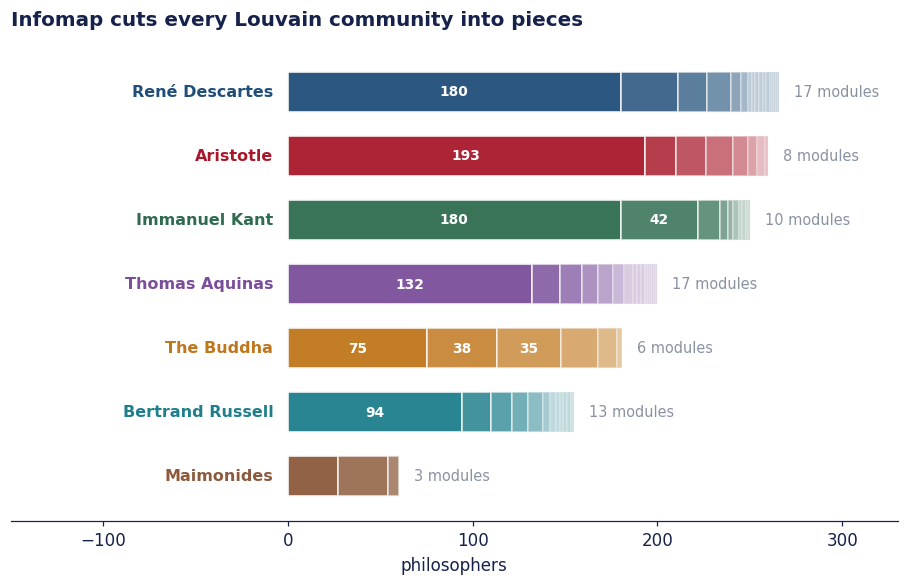

In [7]:
# where does Infomap cut a Louvain community?
big = [c for c in sorted(set(lab_lu), key=lambda c: -sum(lab_lu == c)) if sum(lab_lu == c) > 2]
col = {c: PAL[i % len(PAL)] for i, c in enumerate(
    sorted(set(lab_lu), key=lambda c: -sum(lab_lu == c)))}   # every community, big or tiny

fig, ax = plt.subplots(figsize=(10.4, 5.6))
for row, c in enumerate(big):
    members = [i for i in range(len(order)) if lab_lu[i] == c]
    sub = collections.Counter(lab_im[i] for i in members)
    x = 0
    parts = sorted(sub.items(), key=lambda kv: -kv[1])
    for j, (mod, cnt) in enumerate(parts):
        ax.barh(row, cnt, left=x, height=.62, color=col[c],
                alpha=0.95 - 0.11*min(j, 6), edgecolor=marvel.CARD, linewidth=1.1)
        if cnt >= 34:
            ax.text(x + cnt/2, row, str(cnt), ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
        x += cnt
    ax.text(-8, row, cname[c], ha="right", va="center", fontsize=10.5,
            fontweight="bold", color=col[c])
    ax.text(x + 8, row, f"{len(parts)} modules", ha="left", va="center",
            fontsize=9.5, color=marvel.MUTED)

ax.set_yticks([]); ax.set_ylim(-.7, len(big) - .3); ax.invert_yaxis()
ax.set_xlim(-150, 330); ax.set_xlabel("philosophers")
ax.spines["left"].set_visible(False)
ax.set_title("Infomap cuts every Louvain community into pieces", loc="left",
             fontsize=13, fontweight="bold", pad=14)
marvel.save(fig, 4, "louvain_vs_infomap")
plt.show()

## 4. Which tradition is Aristotle really in?

A partition must put him in exactly one community. The question is what that
costs. Two ways to look: where his links actually go, and whether an
*overlapping* method puts him in more than one place.

In [8]:
ARI = next(v for v in GC if name[v] == "Aristotle")
print(f"Aristotle: degree {deg[ARI]}, strength {strength[ARI]}")
print(f"Louvain puts him in: {cname[lab_lu[idx[ARI]]]}\n")

by_com = collections.Counter(lab_lu[idx[w]] for w in GC[ARI])
for c, k in by_com.most_common():
    print(f"  {cname[c]:<26} {k:>3} links  {100*k/deg[ARI]:>4.0f}%")
print("\nHis own community holds 45% of his links. The partition is not wrong —")
print("it is just answering a question with one slot for an eight-slot answer.")

Aristotle: degree 300, strength 521
Louvain puts him in: Aristotle

  Aristotle                  136 links    45%
  Thomas Aquinas              67 links    22%
  René Descartes              34 links    11%
  Immanuel Kant               30 links    10%
  Bertrand Russell            17 links     6%
  Maimonides                  13 links     4%
  The Buddha                   2 links     1%
  Jules Barthélemy-Saint-Hilaire   1 links     0%

His own community holds 45% of his links. The partition is not wrong —
it is just answering a question with one slot for an eight-slot answer.


In [9]:
for k in (3, 4, 5, 6):
    cc = [set(c) for c in k_clique_communities(GC, k)]
    covered = set().union(*cc)
    mine = [c for c in cc if ARI in c]
    print(f"k={k}: {len(cc):>3} communities, largest {max(len(c) for c in cc):>4}, "
          f"{len(covered):>4} covered ({100*len(covered)/n:.0f}%), Aristotle in {len(mine)}")

cc5 = [set(c) for c in k_clique_communities(GC, 5)]
print("\nAristotle's six k=5 communities:")
for c in sorted([c for c in cc5 if ARI in c], key=len, reverse=True):
    top = sorted(c, key=lambda v: -deg[v])[:7]
    print(f"  [{len(c):>3}]  {', '.join(short(v) for v in top)}")

overlap = collections.Counter()
for c in cc5:
    for v in c:
        overlap[v] += 1
print("\nmost overlapping at k=5:",
      ", ".join(f"{short(v)} ({k})" for v, k in overlap.most_common(6)))

k=3:  19 communities, largest 1155, 1189 covered (87%), Aristotle in 1


k=4:  36 communities, largest  817,  909 covered (66%), Aristotle in 1


k=5:  40 communities, largest  467,  555 covered (40%), Aristotle in 6
k=6:  39 communities, largest  171,  304 covered (22%), Aristotle in 7



Aristotle's six k=5 communities:
  [467]  Aristotle, Plato, Immanuel Kant, Georg Wilhelm Friedrich Hegel, Thomas Aquinas, René Descartes, Friedrich Nietzsche
  [  9]  Aristotle, Plato, Boethius, Anselm of Canterbury, William of Conches, John of Salisbury, Adelard of Bath
  [  8]  Aristotle, Boethius, William of Ockham, Nicole Oresme, Thomas Bradwardine, Jean Buridan, Albert of Saxony (philosopher)
  [  6]  Aristotle, Avicenna, Al-Farabi, Jamal al-Din al-Afghani, Mulla Sadra, Mir Damad
  [  5]  Aristotle, Thomas Aquinas, Averroes, Lucilio Vanini, Pietro Pomponazzi
  [  5]  Aristotle, Edmund Husserl, Martin Heidegger, Max Scheler, Nicolai Hartmann

most overlapping at k=5: Aristotle (6), Augustine of Hippo (5), Thomas Aquinas (5), Friedrich Nietzsche (5), Plato (4), Edmund Husserl (4)


wrote weeks/week4/figures/aristotle.svg


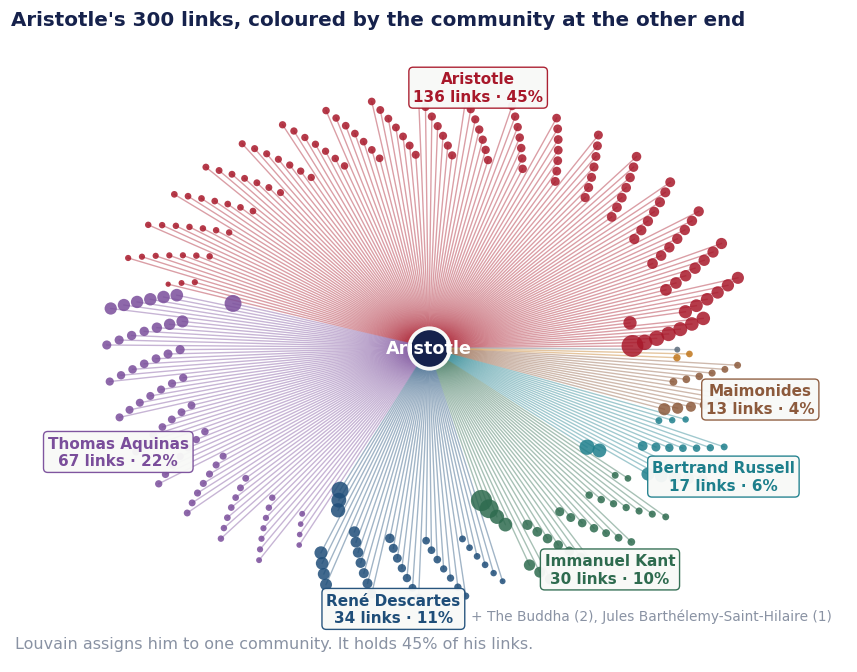

In [10]:
nb_by = collections.defaultdict(list)
for w in GC[ARI]:
    nb_by[lab_lu[idx[w]]].append(w)
ordered = sorted(nb_by, key=lambda c: -len(nb_by[c]))

pos = {ARI: np.array([0., 0.])}
ang, total, lp = 0.0, deg[ARI], []
for c in ordered:
    mem = sorted(nb_by[c], key=lambda v: -deg[v])
    span = 2*np.pi*len(mem)/total
    for j, w in enumerate(mem):
        a = ang + span*(j + .5)/len(mem)
        r = 1.0 + 0.42*(j % 7)/7 + (0.0 if deg[w] > 60 else 0.22)
        pos[w] = np.array([r*np.cos(a), r*np.sin(a)])
    lp.append((c, ang + span/2, len(mem)))
    ang += span

fig, ax = plt.subplots(figsize=(9.8, 7.4))
for c in ordered:
    for w in nb_by[c]:
        ax.plot([0, pos[w][0]], [0, pos[w][1]], color=col[c], alpha=.42, lw=.9, zorder=1)
        ax.scatter(*pos[w], s=10 + 2.0*np.sqrt(deg[w])**1.7, color=col[c],
                   alpha=.85, edgecolors="none", zorder=2)
ax.scatter(0, 0, s=700, color=marvel.INK, zorder=5, edgecolors=marvel.CARD, linewidths=2.5)
ax.text(0, -0.005, "Aristotle", ha="center", va="center", color="white",
        fontsize=11.5, fontweight="bold", zorder=6)
tiny = []
for c, mid, k in lp:
    if k < 8:
        tiny.append((cname[c], k)); continue
    ax.text(1.66*np.cos(mid), 1.66*np.sin(mid),
            f"{cname[c]}\n{k} links · {100*k/total:.0f}%",
            ha="center", va="center", fontsize=10, fontweight="bold", color=col[c],
            bbox=dict(boxstyle="round,pad=.28", fc=marvel.CARD, ec=col[c], lw=.9, alpha=.96))
ax.text(1.98, -1.72, "+ " + ", ".join(f"{t} ({k})" for t, k in tiny),
        ha="right", fontsize=9, color=marvel.MUTED)
ax.set_xlim(-2.05, 2.05); ax.set_ylim(-1.98, 1.98); ax.axis("off")
ax.set_title("Aristotle's 300 links, coloured by the community at the other end",
             loc="left", fontsize=13, fontweight="bold", pad=6)
ax.text(-2.03, -1.90, "Louvain assigns him to one community. It holds 45% of his links.",
        fontsize=10.5, color=marvel.MUTED)
marvel.save(fig, 4, "aristotle")
plt.show()

## 5. The backbone, and where it breaks

The disparity filter is a **per-node** null: spread node *i*'s strength evenly
over its links, and ask how surprising the observed share is. With
$p_{ij} = w_{ij}/s_i$, a link is significant for *i* when
$(1-p_{ij})^{k_i-1} < \alpha$. Keep it if it passes at *either* end.

Written literally, a degree-1 node gives $(1-p)^0 = 1$, which never passes —
so such a link survives only for the sake of the node at the other end. We got
this wrong first time by special-casing degree 1, and the table below is how we
caught it.

In [11]:
# marvel.disparity_filter implements Serrano et al. (2009); see src/marvel.py
def backbone(alpha):
    return marvel.disparity_filter(GC, alpha)

published = {0.05: (292, 348, 116), 0.10: (649, 607, 419), 0.20: (1540, 950, 816),
             0.30: (2549, 1111, 1052), 0.50: (5641, 1284, 1270)}
print(f"{'alpha':>6}{'links':>8}{'attached':>10}{'giant':>8}   vs course page")
for a, want in published.items():
    H = backbone(a)
    got = (H.number_of_edges(), H.number_of_nodes(),
           len(max(nx.connected_components(H), key=len)))
    print(f"{a:>6.2f}{got[0]:>8}{got[1]:>10}{got[2]:>8}   {'OK' if got == want else 'MISMATCH ' + str(want)}")

 alpha   links  attached   giant   vs course page
  0.05     292       348     116   OK
  0.10     649       607     419   OK


  0.20    1540       950     816   OK
  0.30    2549      1111    1052   OK
  0.50    5641      1284    1270   OK


In [12]:
alphas = np.round(np.arange(0.02, 0.505, 0.005), 4)
curve = []
for a in alphas:
    H = backbone(a)
    curve.append([float(a), H.number_of_edges(), H.number_of_nodes(),
                  len(max(nx.connected_components(H), key=len)) if H.number_of_nodes() else 0])
c = np.array(curve)

# two ways to ask "where does it break", and they answer differently
absolute = np.diff(c[:, 3])
relative = absolute / np.maximum(c[:-1, 3], 1)
j_abs, j_rel = int(np.argmax(absolute)), int(np.argmax(relative))
print(f"largest ABSOLUTE jump: alpha {c[j_abs,0]:.3f} -> {c[j_abs+1,0]:.3f}, "
      f"giant {c[j_abs,3]:.0f} -> {c[j_abs+1,3]:.0f}  (+{absolute[j_abs]:.0f})")
print(f"largest RELATIVE jump: alpha {c[j_rel,0]:.3f} -> {c[j_rel+1,0]:.3f}, "
      f"giant {c[j_rel,3]:.0f} -> {c[j_rel+1,3]:.0f}  (x{1+relative[j_rel]:.2f})")
print("link doubles it. We report the absolute jump: it is where the backbone")
print("stops being fragments and starts being a network.")
j = j_abs

a_lo, a_hi = float(c[j, 0]), float(c[j+1, 0])
g_lo = max(nx.connected_components(backbone(a_lo)), key=len)
H_lo, H_hi = backbone(a_lo), backbone(a_hi)
new = [(u, v) for u, v in H_hi.edges() if not H_lo.has_edge(u, v)]
merging = [(u, v) for u, v in new if (u in g_lo) != (v in g_lo)]
carriers = collections.Counter()
for u, v in merging:
    carriers[u] += 1; carriers[v] += 1
print(f"\n{len(new)} links become significant in that step; {len(merging)} touch the giant.")
print("who carries them:")
for v, k in carriers.most_common(6):
    print(f"   {short(v):<24} {k} bridging link(s)   degree {deg[v]:>3}, strength {strength[v]:>3}")

largest ABSOLUTE jump: alpha 0.050 -> 0.055, giant 116 -> 178  (+62)
largest RELATIVE jump: alpha 0.030 -> 0.035, giant 24 -> 46  (x1.92)
link doubles it. We report the absolute jump: it is where the backbone
stops being fragments and starts being a network.

33 links become significant in that step; 10 touch the giant.
who carries them:
   Baruch Spinoza           2 bridging link(s)   degree 103, strength 178
   Proclus                  2 bridging link(s)   degree  40, strength  69
   Galen                    1 bridging link(s)   degree  49, strength  85
   Aristotle                1 bridging link(s)   degree 300, strength 521
   David Hume               1 bridging link(s)   degree  99, strength 168
   Jean-Jacques Rousseau    1 bridging link(s)   degree  80, strength 145


In [13]:
H = backbone(0.10)
g0 = len(max(nx.connected_components(H), key=len))
damage = []
for v in H.nodes():
    K = H.subgraph([x for x in H if x != v])
    damage.append((g0 - 1 - len(max(nx.connected_components(K), key=len)), v))
damage.sort(reverse=True)
print(f"at alpha = 0.10 the giant holds {g0}. Removing one philosopher strands:")
for s_, v in damage[:6]:
    print(f"   {short(v):<24} strands {s_:>3}   (backbone degree {H.degree(v)})")

at alpha = 0.10 the giant holds 419. Removing one philosopher strands:
   Aristotle                strands  12   (backbone degree 22)
   Leo Strauss              strands  10   (backbone degree 6)
   Immanuel Kant            strands  10   (backbone degree 18)
   Diogenes Laertius        strands  10   (backbone degree 8)
   Charles Sanders Peirce   strands  10   (backbone degree 8)
   Karl Marx                strands   9   (backbone degree 9)


/tmp/ipykernel_377/2844816516.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, .93])


wrote weeks/week4/figures/backbone.svg


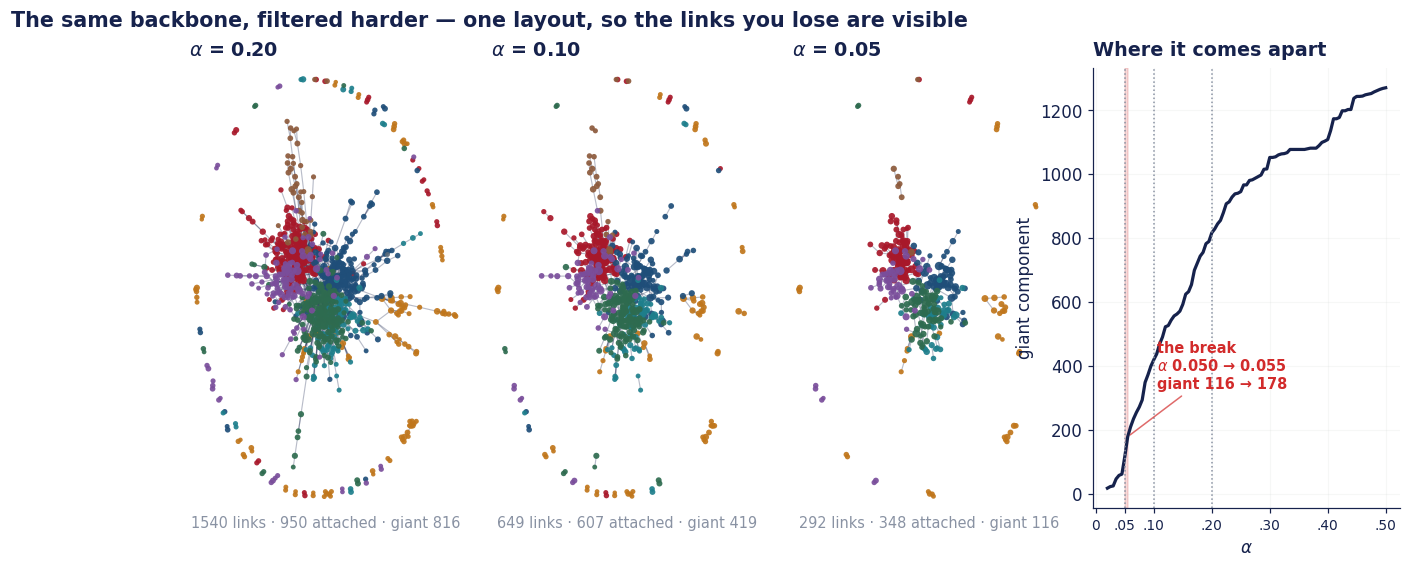

In [14]:
H20 = backbone(0.20)
pos_b = nx.spring_layout(H20, seed=11, k=.42, iterations=420)   # ONE layout, reused

fig = plt.figure(figsize=(14.2, 5.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.12], wspace=.10)
for k, a in enumerate([0.20, 0.10, 0.05]):
    ax = fig.add_subplot(gs[0, k])
    H = backbone(a)
    H = H.subgraph([v for v in H if v in pos_b])
    giant = max(nx.connected_components(H), key=len)
    nx.draw_networkx_edges(H, pos_b, ax=ax, edge_color=marvel.INK, alpha=.30, width=.75)
    for cm in sorted(set(lab_lu)):            # not `c` — that is the curve array
        vs = [v for v in H if lab_lu[idx[v]] == cm]
        if vs:
            nx.draw_networkx_nodes(H, pos_b, nodelist=vs, ax=ax,
                                   node_size=[6 + 2.4*np.sqrt(deg[v]) for v in vs],
                                   node_color=col.get(cm, GREY), alpha=.92, linewidths=0)
    ax.set_title(rf"$\alpha$ = {a:.2f}", loc="left", fontsize=12.5, fontweight="bold", pad=8)
    ax.text(.5, -.045, f"{H.number_of_edges()} links · {H.number_of_nodes()} attached · giant {len(giant)}",
            transform=ax.transAxes, ha="center", fontsize=9.5, color=marvel.MUTED)
    xs = [p[0] for p in pos_b.values()]; ys = [p[1] for p in pos_b.values()]
    ax.set_xlim(min(xs)-.05, max(xs)+.05); ax.set_ylim(min(ys)-.05, max(ys)+.05)
    ax.axis("off")

ax = fig.add_subplot(gs[0, 3])
ax.plot(c[:, 0], c[:, 3], "-", color=marvel.INK, lw=2.1)
ax.axvspan(a_lo, a_hi, color=marvel.RED, alpha=.16)
ax.annotate(f"the break\n$\\alpha$ {a_lo:.3f} → {a_hi:.3f}\ngiant {c[j,3]:.0f} → {c[j+1,3]:.0f}",
            xy=(a_hi, c[j+1, 3]), xytext=(0.105, 330), fontsize=9.5,
            color=marvel.RED, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=marvel.RED, lw=1, alpha=.7))
for a in (0.05, 0.10, 0.20):
    ax.axvline(a, color=marvel.MUTED, ls=":", lw=1)
ax.set_xticks([0, .05, .1, .2, .3, .4, .5])
ax.set_xticklabels(["0", ".05", ".10", ".20", ".30", ".40", ".50"], fontsize=9)
ax.set_xlabel(r"$\alpha$"); ax.set_ylabel("giant component")
ax.set_title("Where it comes apart", loc="left", fontsize=12.5, fontweight="bold", pad=8)
ax.grid(alpha=.15, color=marvel.RULE)
fig.suptitle("The same backbone, filtered harder — one layout, so the links you lose are visible",
             x=.011, ha="left", fontsize=13.5, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, .93])
marvel.save(fig, 4, "backbone")
plt.show()

## 6. Does weight change the story?

Weighted Louvain replaces link counts with weights and degrees with strengths.
The two modularities are **not comparable** — they score different quantities —
so the question is not which is higher, but which philosophers move.

In [15]:
louv_w = louvain_communities(GC, weight="weight", seed=42)
Qw = modularity(GC, louv_w, weight="weight")
lab_lw = labels_of(louv_w)
wname = {}
for c in set(lab_lw):
    mem = [order[i] for i in range(len(order)) if lab_lw[i] == c]
    wname[c] = short(max(mem, key=lambda v: deg[v]))

print(f"weighted:   {len(louv_w)} communities, weighted Q = {Qw:.4f}   course page: 9, 0.55")
print(f"unweighted: {len(louv)} communities, Q = {Q:.4f}")
print(f"NMI between them: {nmi(lab_lu, lab_lw):.4f}")
print("\nweighted communities:", ", ".join(wname[c] for c in sorted(wname)))

weighted:   10 communities, weighted Q = 0.5645   course page: 9, 0.55
unweighted: 8 communities, Q = 0.5059
NMI between them: 0.6638

weighted communities: Thomas Aquinas, Avicenna, Bertrand Russell, Confucius, René Descartes, Immanuel Kant, Karl Marx, P. D. Ouspensky, The Buddha, Aristotle


In [16]:
cross = collections.Counter((lab_lu[i], lab_lw[i]) for i in range(len(order)))
home = {c: max([k for k in cross if k[0] == c], key=lambda k: cross[k])[1] for c in set(lab_lu)}
movers = [order[i] for i in range(len(order)) if lab_lw[i] != home[lab_lu[i]]]

print(f"{len(movers)} of {len(order)} philosophers ({100*len(movers)/len(order):.0f}%) "
      f"land somewhere else once weights are counted.\n")
for v in sorted(movers, key=lambda v: -deg[v])[:10]:
    print(f"  {short(v):<24} {cname[lab_lu[idx[v]]]:<20} -> {wname[lab_lw[idx[v]]]:<20}"
          f" deg {deg[v]:>3} str {strength[v]:>3}")

376 of 1374 philosophers (27%) land somewhere else once weights are counted.

  Baruch Spinoza           René Descartes       -> Immanuel Kant        deg 103 str 178
  Karl Marx                Immanuel Kant        -> Karl Marx            deg  96 str 196
  Avicenna                 Aristotle            -> Avicenna             deg  65 str 131
  Averroes                 Aristotle            -> Avicenna             deg  55 str 116
  Galileo Galilei          Aristotle            -> René Descartes       deg  52 str 100
  Niccolò Machiavelli      René Descartes       -> Immanuel Kant        deg  52 str  73
  Roger Bacon              Thomas Aquinas       -> Avicenna             deg  49 str  91
  Boethius                 Thomas Aquinas       -> Aristotle            deg  47 str  71
  Kitarō Nishida           René Descartes       -> Immanuel Kant        deg  45 str  59
  Leo Tolstoy              Immanuel Kant        -> Karl Marx            deg  43 str  72


wrote weeks/week4/figures/strength_degree.svg


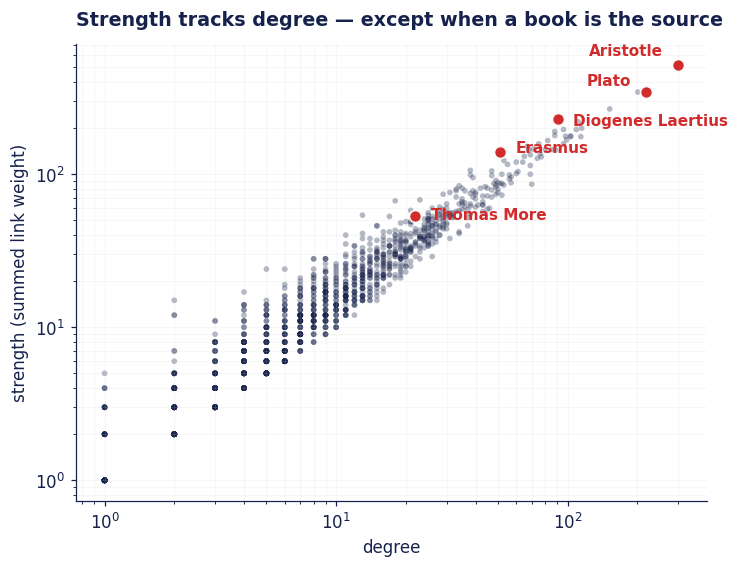

Spearman(degree, strength) = 0.958     course page: 0.96
Diogenes Laertius: degree 91 (rank 15), strength 230 (rank 5)


In [17]:
fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.scatter([deg[v] for v in GC], [strength[v] for v in GC],
           s=14, color=marvel.INK, alpha=.32, edgecolors="none")
for who, dx, dy in [("Diogenes Laertius", 10, -4), ("Aristotle", -10, 6),
                    ("Erasmus", 10, 0), ("Thomas More", 10, -2), ("Plato", -10, 4)]:
    v = next((x for x in GC if short(x) == who), None)
    if v is None:
        continue
    ax.scatter([deg[v]], [strength[v]], s=62, color=marvel.RED, zorder=5,
               edgecolors=marvel.CARD, linewidths=1.1)
    ax.annotate(who, (deg[v], strength[v]), textcoords="offset points", xytext=(dx, dy),
                fontsize=10, color=marvel.RED, fontweight="bold",
                ha="left" if dx > 0 else "right")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("degree"); ax.set_ylabel("strength (summed link weight)")
ax.set_title("Strength tracks degree — except when a book is the source",
             loc="left", fontsize=12.5, fontweight="bold", pad=12)
ax.grid(alpha=.15, color=marvel.RULE, which="both")
marvel.save(fig, 4, "strength_degree")
plt.show()

from scipy.stats import spearmanr
r = spearmanr([deg[v] for v in GC], [strength[v] for v in GC]).statistic
print(f"Spearman(degree, strength) = {r:.3f}     course page: 0.96")
dl = next(v for v in GC if short(v) == "Diogenes Laertius")
dr = sorted(GC, key=lambda v: -deg[v]).index(dl) + 1
sr = sorted(GC, key=lambda v: -strength[v]).index(dl) + 1
print(f"Diogenes Laertius: degree {deg[dl]} (rank {dr}), strength {strength[dl]} (rank {sr})")